# Statistical associations with eddy tilt magnitude

This notebook addresses the explanatory question separately from ML prediction: **which surface and environmental feature groups have stable associations with tilt magnitude?** AE and CE are analysed independently.

The primary model is a Gaussian generalized estimating equation (GEE) for `log1p(TiltDis)`. Eddy is the clustering unit, giving cluster-robust uncertainty for repeated eddy-days. Nonlinear spline terms describe effect shape. Time-varying predictors are decomposed into between-eddy means and within-eddy daily anomalies. Results are associations, not causal effects.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
import patsy

import seacofs_tilt_tools as tilt
import ml_subsurface_tools as ml

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42
GRID_ROTATION_DEG = 20.0
N_BOOT = 1000
print("statsmodels", statsmodels.__version__, "patsy", patsy.__version__)

statsmodels 0.14.6 patsy 1.0.2


## 1. Predeclared hypotheses

- **Environment:** greater `abs(beta)` is associated with greater tilt magnitude; bathymetry may capture regional constraint.
- **Structure:** `Rc`, `Omega`, and ellipse orientation are associated with magnitude.
- **PV:** PV-gradient magnitude is associated with tilt magnitude; PV direction is retained as an adjustment variable.
- **Propagation:** between-eddy propagation may represent EAC pathway, whereas within-eddy anomalies test whether daily propagation changes accompany tilt changes.

Stability requires compatible eddy-level and repeated-measures results, physically meaningful effect size, and robustness to covariance/spatial sensitivity—not merely a small p-value.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
df_vert = tilt.load_vert(paths)

max_depth = (df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
             .max().rename(columns={"Depth": "max_profile_depth"}))
df_eddies = df_eddies.merge(max_depth, on=["Eddy", "Day"], how="inner")
df_eddies = df_eddies[df_eddies["max_profile_depth"] > 850].copy()
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

# only condier planetary eddies
df_eddies = df_eddies[df_eddies.topo_plan_ratio<0].copy()

model_df = ml.prepare_modelling_table(df_eddies, grid_rotation_deg=GRID_ROTATION_DEG)
polarity_data = {cyc: model_df[model_df["Cyc"] == cyc].copy() for cyc in ("AE", "CE")}
display(pd.DataFrame({cyc: {"rows": len(x), "eddies": x.Eddy.nunique()}
                      for cyc, x in polarity_data.items()}).T)

,rows,eddies
AE,12722,694
CE,4446,546


## 2. One-row-per-eddy descriptive analysis

This prevents long-lived eddies from dominating and provides transparent unadjusted associations. Confidence intervals resample complete eddies. Because beta is signed under the model-grid convention, `abs_beta` is used for the physical beta-magnitude hypothesis.

In [3]:
eddy_summary = ml.eddy_level_association_table(model_df)
predictors = ["abs_beta", "Rc", "Omega", "h", "PV_grad_mag",
              "prop_east", "prop_north"]
eddy_correlations = {}
for cyc in ("AE", "CE"):
    part = eddy_summary[eddy_summary["Cyc"] == cyc].copy()
    result = ml.eddy_level_spearman_table(
        part, predictors, n_boot=N_BOOT, random_state=RANDOM_STATE
    )
    eddy_correlations[cyc] = result
    print(cyc)
    display(result.round(3))

AE


,y,clusters,spearman_rho,CI_low,CI_high
x,,,,,
Rc,tilt_magnitude,694,-0.167,-0.242,-0.100
h,tilt_magnitude,694,-0.097,-0.168,-0.024
PV_grad_mag,tilt_magnitude,694,-0.092,-0.173,-0.014
prop_north,tilt_magnitude,611,-0.053,-0.138,0.028
Omega,tilt_magnitude,694,-0.030,-0.109,0.050
prop_east,tilt_magnitude,611,-0.006,-0.088,0.083
abs_beta,tilt_magnitude,694,0.302,0.226,0.368


CE


,y,clusters,spearman_rho,CI_low,CI_high
x,,,,,
prop_east,tilt_magnitude,442,-0.177,-0.274,-0.088
prop_north,tilt_magnitude,442,-0.167,-0.259,-0.067
PV_grad_mag,tilt_magnitude,546,-0.051,-0.135,0.033
h,tilt_magnitude,546,-0.046,-0.125,0.033
Rc,tilt_magnitude,546,0.006,-0.079,0.085
Omega,tilt_magnitude,546,0.169,0.084,0.253
abs_beta,tilt_magnitude,546,0.334,0.245,0.410


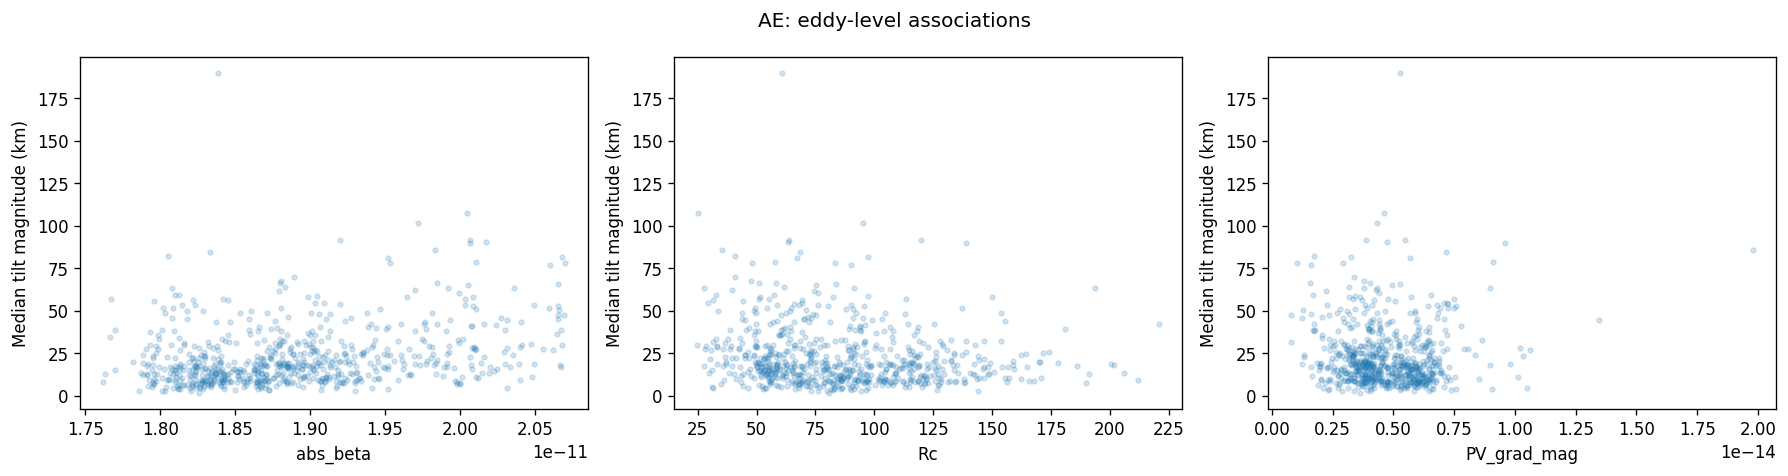

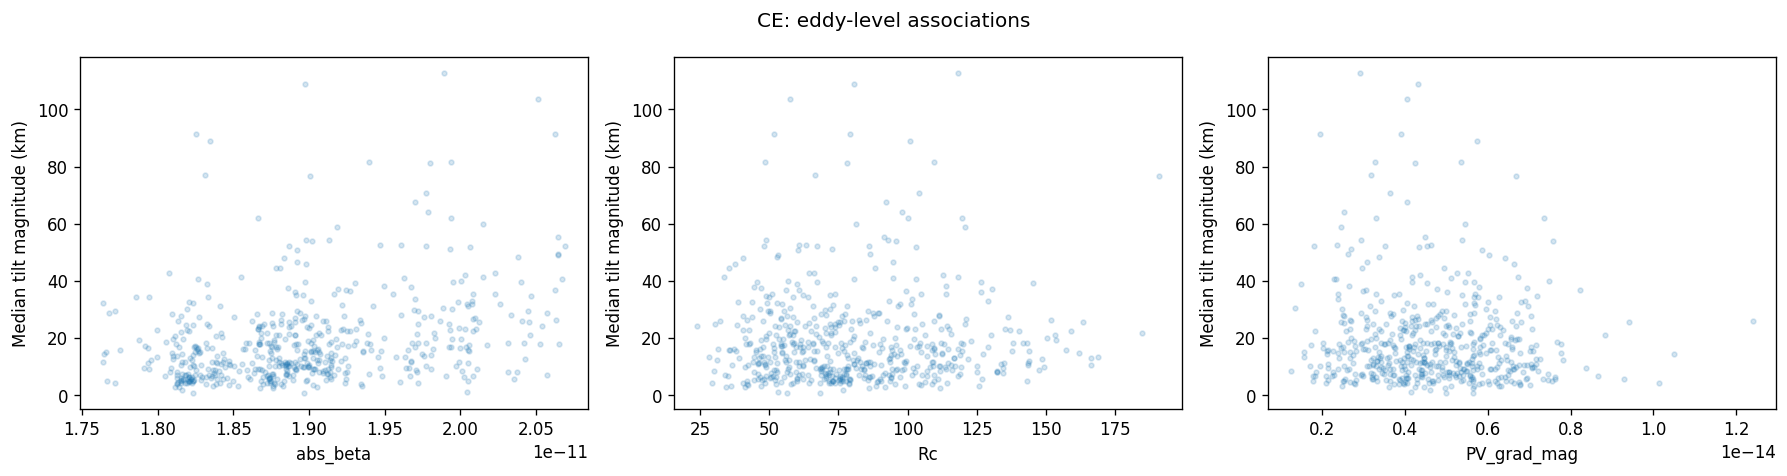

In [4]:
for cyc in ("AE", "CE"):
    part = eddy_summary[eddy_summary["Cyc"] == cyc]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, predictor in zip(axes, ["abs_beta", "Rc", "PV_grad_mag"]):
        ax.scatter(part[predictor], part["tilt_magnitude"], s=8, alpha=0.18)
        ax.set(xlabel=predictor, ylabel="Median tilt magnitude (km)")
    fig.suptitle(f"{cyc}: eddy-level associations")
    fig.tight_layout()

## 3. Within-eddy and between-eddy decomposition

For `X_between`, ask whether eddies with characteristically larger X have different tilt. For `X_within`, ask whether the same eddy tilts differently when X departs from its own mean. All continuous decomposed variables are standardised separately within AE and CE before spline fitting.

In [5]:
association_data = {}
association_scaling = {}
for cyc, part in polarity_data.items():
    association_data[cyc], association_scaling[cyc] = ml.prepare_association_table(part)

display(association_scaling["AE"].head(14))

,mean,sd
column,,
abs_beta_between,1.881248e-11,5.094197e-13
abs_beta_within,1.114986e-28,1.653346e-13
Rc_between,9.553751e+01,2.899946e+01
Rc_within,4.736207e-16,1.595700e+01
Omega_between,1.424112e-05,6.167600e-06
Omega_within,2.743103e-23,3.269212e-06
h_between,4.728607e+03,1.367339e+02
h_within,1.697885e-14,5.452275e+01
PV_grad_mag_between,4.660684e-15,1.090992e-15


## 4. Full clustered nonlinear magnitude model

The exchangeable GEE estimates population-averaged associations while allowing repeated observations from an eddy to be correlated. Joint robust Wald tests assess predeclared groups. With this sample size, p-values can be tiny for negligible effects; prioritise the effect curves and agreement with grouped predictive ablation.

In [6]:
magnitude_gee = {}
magnitude_fit_data = {}
for cyc in ("AE", "CE"):
    print(f"Fitting {cyc} magnitude GEE...")
    result, fit_data = ml.fit_magnitude_gee(association_data[cyc], covariance="exchangeable")
    magnitude_gee[cyc] = result
    magnitude_fit_data[cyc] = fit_data
    print(result.summary())
    display(ml.gee_group_wald_table(result).round(4))

Fitting AE magnitude GEE...
                               GEE Regression Results                              
Dep. Variable:                    log_tilt   No. Observations:                12028
Model:                                 GEE   No. clusters:                      611
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                 303
Family:                           Gaussian   Mean cluster size:                19.7
Dependence structure:         Exchangeable   Num. iterations:                    11
Date:                     Mon, 24 Aug 2026   Scale:                           0.466
Covariance type:                    robust   Time:                         12:40:35
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept 

,parameters_tested,wald_statistic,p_value
group,,,
beta,10,155.7434,0.0000
environment,22,181.3184,0.0000
structure,22,132.4551,0.0000
PV,12,28.1819,0.0052
propagation,4,14.0721,0.0071
ellipse,2,3.2133,0.2006


Fitting CE magnitude GEE...
                               GEE Regression Results                              
Dep. Variable:                    log_tilt   No. Observations:                 3900
Model:                                 GEE   No. clusters:                      442
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  55
Family:                           Gaussian   Mean cluster size:                 8.8
Dependence structure:         Exchangeable   Num. iterations:                     9
Date:                     Mon, 24 Aug 2026   Scale:                           0.411
Covariance type:                    robust   Time:                         12:40:35
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept 

,parameters_tested,wald_statistic,p_value
group,,,
environment,22,382.0493,0.0000
beta,10,216.5733,0.0000
structure,22,156.2225,0.0000
propagation,4,27.4519,0.0000
PV,12,28.6534,0.0044
ellipse,2,4.1066,0.1283


## 5. Physical effect curves

Curves vary one predictor while holding the others at their medians. Shading is the cluster-robust pointwise 95% confidence band. Between-beta is the primary theoretical result; within-beta reflects movement through the model's beta field during an eddy track. Curves are conditional associations, not interventions.

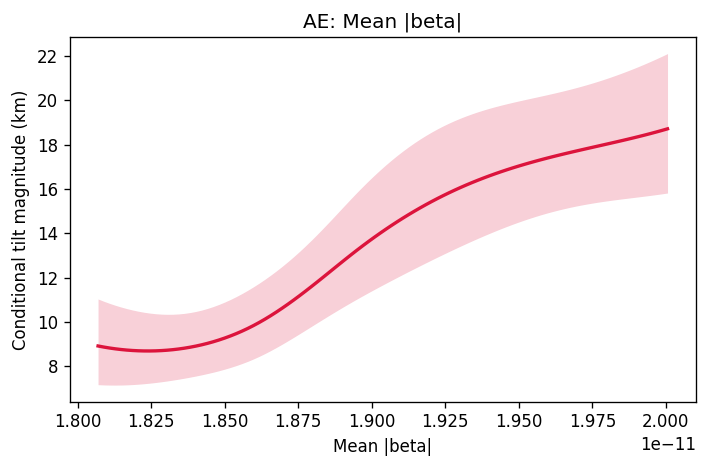

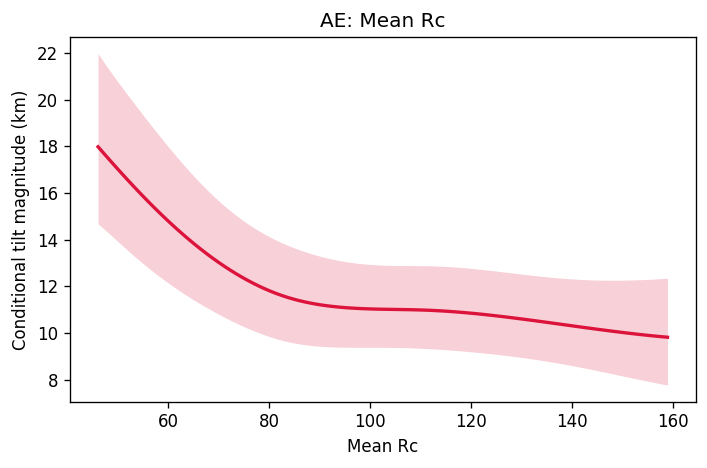

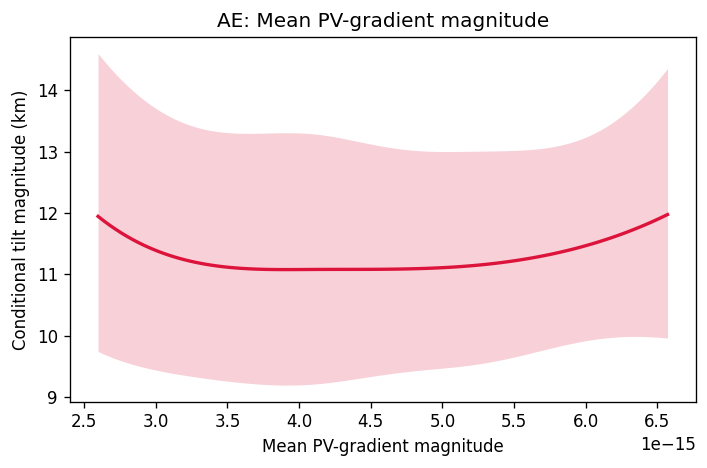

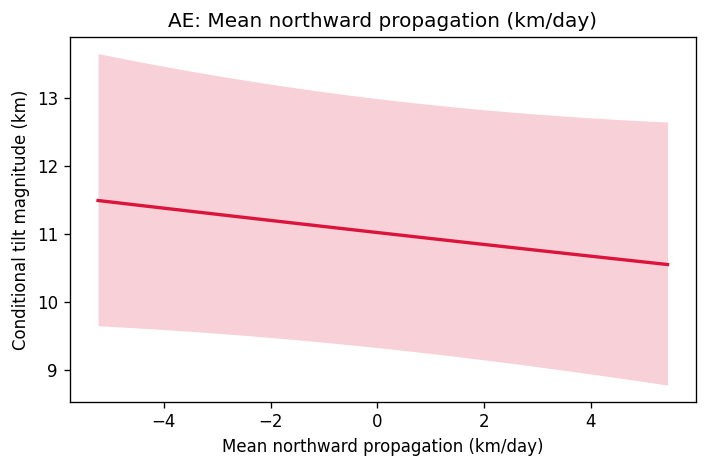

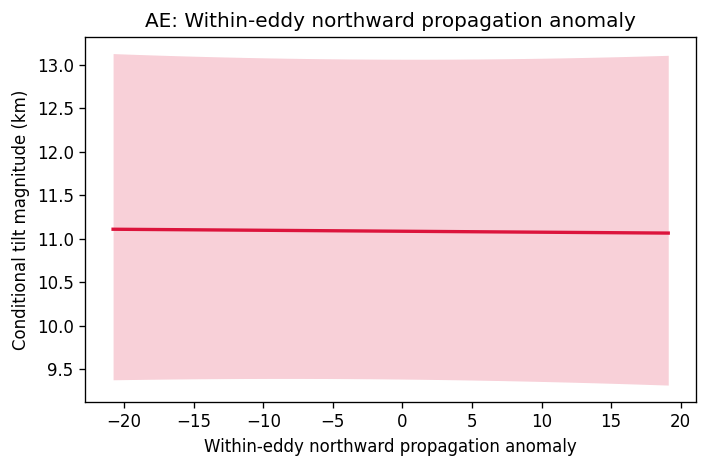

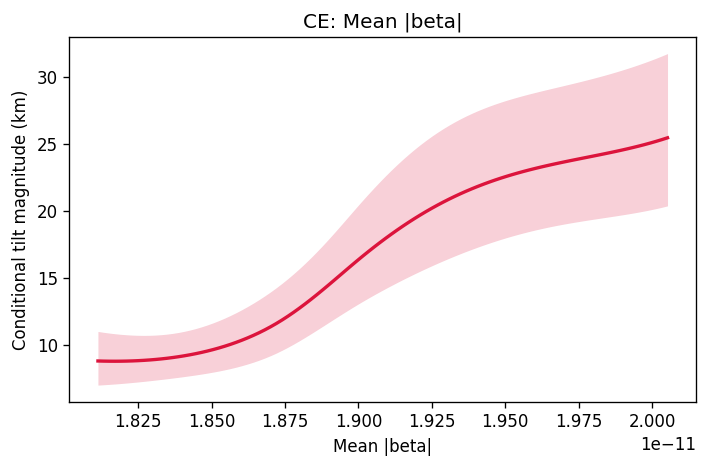

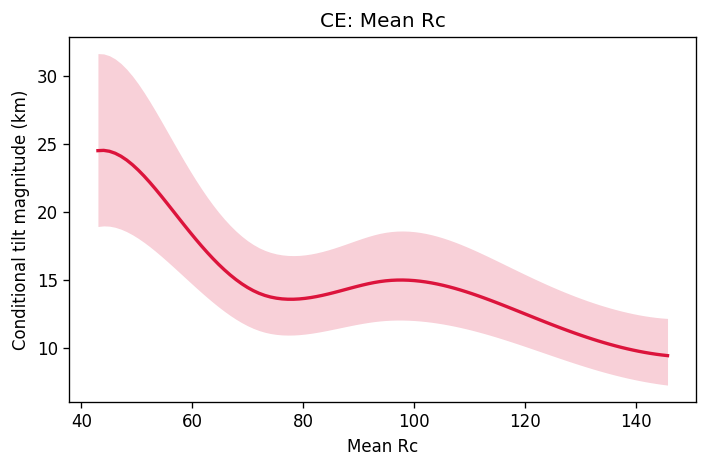

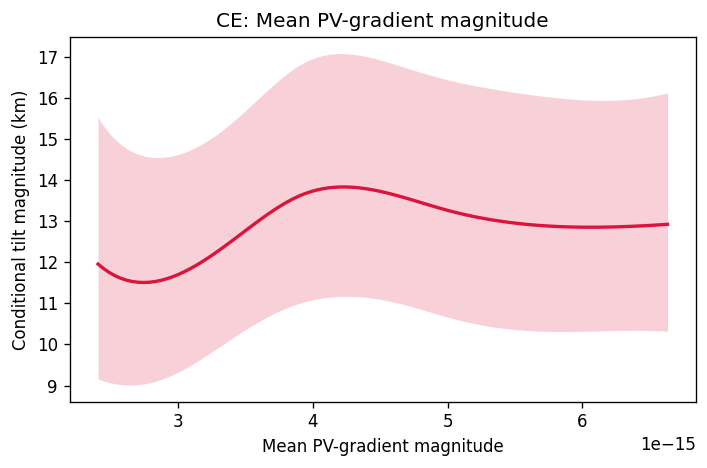

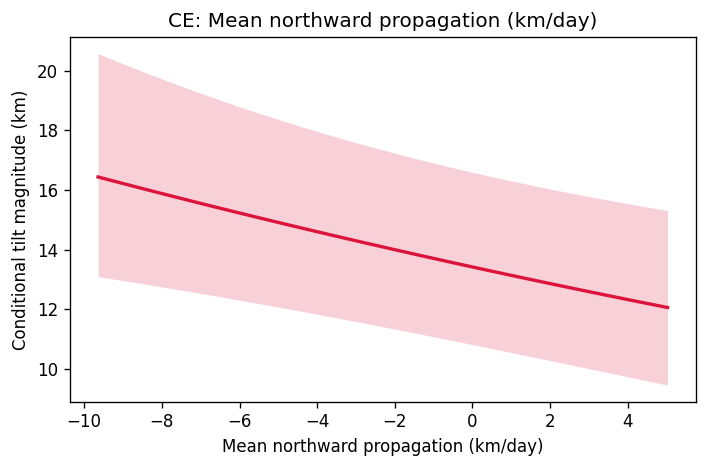

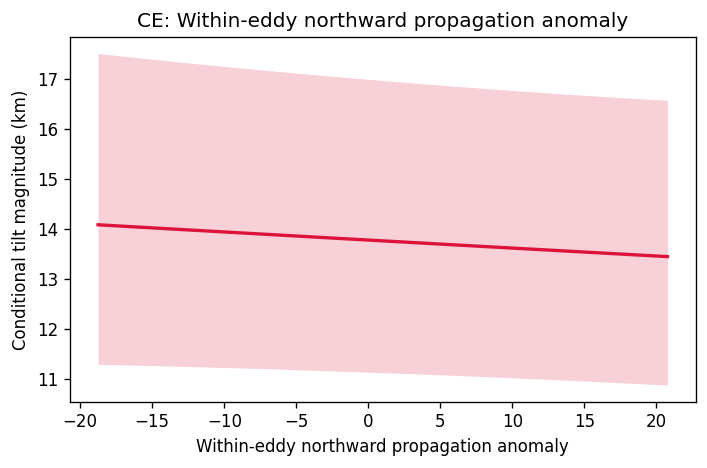

In [7]:
magnitude_curves = {}
curve_features = {
    "abs_beta_between_z": "Mean |beta|",
    "Rc_between_z": "Mean Rc",
    "PV_grad_mag_between_z": "Mean PV-gradient magnitude",
    "prop_north_km_day_between_z": "Mean northward propagation (km/day)",
    "prop_north_km_day_within_z": "Within-eddy northward propagation anomaly",
}
for cyc in ("AE", "CE"):
    magnitude_curves[cyc] = {}
    for feature, label in curve_features.items():
        curve = ml.gee_effect_curve(
            magnitude_gee[cyc], magnitude_fit_data[cyc], feature,
            scaling=association_scaling[cyc], response_transform=np.expm1,
        )
        magnitude_curves[cyc][feature] = curve
        ml.plot_association_curve(curve, xlabel=label, ylabel="Conditional tilt magnitude (km)",
                                  title=f"{cyc}: {label}")

## 6. Correlation-structure sensitivity

Refit using working independence. Point estimates should remain broadly compatible; large changes indicate sensitivity to the assumed within-eddy correlation structure. Cluster-robust standard errors are retained.

In [8]:
magnitude_independence = {}
for cyc in ("AE", "CE"):
    result, _ = ml.fit_magnitude_gee(association_data[cyc], covariance="independence")
    magnitude_independence[cyc] = result
    comparison = ml.gee_group_wald_table(result).add_suffix("_independence").join(
        ml.gee_group_wald_table(magnitude_gee[cyc]).add_suffix("_exchangeable"), how="outer"
    )
    print(cyc)
    display(comparison.round(4))

AE


,parameters_tested_independence,wald_statistic_independence,p_value_independence,parameters_tested_exchangeable,wald_statistic_exchangeable,p_value_exchangeable
group,,,,,,
PV,12,34.1674,0.0006,12,28.1819,0.0052
beta,10,180.2567,0.0000,10,155.7434,0.0000
ellipse,2,5.3012,0.0706,2,3.2133,0.2006
environment,22,245.8746,0.0000,22,181.3184,0.0000
propagation,4,21.8291,0.0002,4,14.0721,0.0071
structure,22,150.0567,0.0000,22,132.4551,0.0000


CE


,parameters_tested_independence,wald_statistic_independence,p_value_independence,parameters_tested_exchangeable,wald_statistic_exchangeable,p_value_exchangeable
group,,,,,,
PV,12,14.7256,0.2568,12,28.6534,0.0044
beta,10,167.8573,0.0000,10,216.5733,0.0000
ellipse,2,5.3504,0.0689,2,4.1066,0.1283
environment,22,270.0670,0.0000,22,382.0493,0.0000
propagation,4,31.2338,0.0000,4,27.4519,0.0000
structure,22,134.1923,0.0000,22,156.2225,0.0000


## 7. Reporting template

For each polarity report: (1) eddy-level Spearman effect and bootstrap interval; (2) between-eddy and within-eddy GEE curve shape; (3) feature-group Wald statistic but not p-value alone; (4) compatibility under independence sensitivity; and (5) corresponding nested-ML drop-group change.

Call a group **stably associated** only if effect direction/shape is scientifically meaningful, uncertainty is acceptably narrow, the result is not driven solely by between-eddy geography, and spatial/predictive checks are compatible. Beta cannot be separated completely from other latitude-varying EAC processes using these observational data.